In [200]:
import importlib

import numpy as np
import os
import pandas as pd
import random
from lifelines import CoxPHFitter

import test_WTM as wtm
import utilsA1 as utils

PATH = os.getcwd()
output_file = "cox_proportional_models"
print(PATH)

C:\Users\sranasin\Desktop\NetworkModels\Project1\A1


#### Test And Visualizations

In [206]:
importlib.reload(utils)
importlib.reload(wtm)

params_temp_list = {'num_nodes': 50, 'num_neighbor_nodes': 3,
                    'total_random_edges': 40, 'distance_threshold': 5, 'weighted': True,
                    'random_dist': 'random.choice', 'n_seeds': 2, 'node_active_threshold': 0.02,
                    'upper_weight_limit': 20, 'skew_power': 2, 'seed_cluster_distance': 10}

G, snapshots, activation_times, results = wtm.simulation_record_data(params=params_temp_list,
                                               threshold_sum=sum(range(params_temp_list.get('num_nodes'))) - 1,
                                                sim_id=1)

utils.visualize_step_animation_new(G=G, snapshots=snapshots,
                         output_file= os.path.join(PATH, 'Outputs', f"{output_file}.html"))

#### Cox Proportional Hazard Model

In [209]:
importlib.reload(utils)
importlib.reload(wtm)

###############
## Simulation Runs
threshold_sum = 19900
params_list = utils.generate_random_params(num_samples=500)
np.random.seed(666)
random.seed(666)


df, pkl = wtm.main_sims(params_list=params_list, threshold_sum=threshold_sum,
                   output_file=output_file, save_files=False)
# df = pd.read_csv(os.path.join(PATH, 'Outputs', f"{output_file}.csv"))

In [196]:
df.head()

,simulation_id,num_nodes,time,state,state_abnormal_sum,num_active_nodes,active_nodes,node_active_threshold,num_non_geo_edges,num_seeds,seed_nodes,seed_cluster_distance,weighted,average_weight_per_edge,skew_power,upper_weight_limit,distance_threshold
0,0,200,0,0,19900,2,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",0.18,41,2,"(15, 71)",20,True,7.183673,2,20,7
1,0,200,1,0,19900,4,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",0.18,41,2,"(15, 71)",20,True,7.183673,2,20,7
2,0,200,2,0,19900,6,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",0.18,41,2,"(15, 71)",20,True,7.183673,2,20,7
3,0,200,3,0,19900,10,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",0.18,41,2,"(15, 71)",20,True,7.183673,2,20,7
4,0,200,4,0,19900,16,"[nan, nan, nan, nan, nan, nan, nan, nan, 4.0, ...",0.18,41,2,"(15, 71)",20,True,7.183673,2,20,7


In [210]:
grouped = df.groupby('simulation_id')

records = []
for sim_id, group in grouped:
    abnormal_records = group[group['state'] == 1]
    if not abnormal_records.empty:
        row = abnormal_records.iloc[0]
        time_to_event = row['time']
        state = 1
    else:
        row = group.iloc[-1]
        time_to_event = row['time']
        state = 0

    features = row.drop(['time', 'state', 'simulation_id', 'state_abnormal_sum',
                         'active_nodes', 'num_nodes', 'num_active_nodes',  # 'node_active_threshold', 'skew_power',
                         'seed_nodes']).to_dict()

    records.append({
        'duration': time_to_event,
        'state': state,
        **features
    })

cox_df = pd.DataFrame(records)
cox_df['is_weighted'] = cox_df['weighted'].astype(int)
cox_df.drop(columns = ['weighted'], inplace=True)

# cox_df['state'].value_counts()
print(cox_df[cox_df['state'] ==0]['duration'].value_counts().sort_index())
cox_df.head()
cox_df = cox_df[cox_df['state'] == 1]

duration
0     41
1     10
2      8
3      3
4      4
5      3
6      1
7      1
8      1
13     1
16     2
20     1
21     1
Name: count, dtype: int64


,duration,state,node_active_threshold,num_non_geo_edges,num_seeds,seed_cluster_distance,average_weight_per_edge,skew_power,upper_weight_limit,distance_threshold
0,7,1,0.09,45,4,15,0.000000,4,27,3
1,1,0,0.05,50,1,5,5.780000,2,17,7
2,12,1,0.14,50,1,13,0.000000,3,27,6
3,6,1,0.04,50,3,24,0.000000,2,11,6
4,18,1,0.03,5,3,15,5.358678,2,15,10


Iteration 1: norm_delta = 8.68e-01, step_size = 0.9500, log_lik = -2138.98125, newton_decrement = 1.03e+02, seconds_since_start = 0.0
Iteration 2: norm_delta = 5.67e-02, step_size = 0.9500, log_lik = -2042.22994, newton_decrement = 7.88e-01, seconds_since_start = 0.0
Iteration 3: norm_delta = 3.05e-03, step_size = 0.9500, log_lik = -2041.44347, newton_decrement = 2.24e-03, seconds_since_start = 0.0
Iteration 4: norm_delta = 3.77e-06, step_size = 1.0000, log_lik = -2041.44122, newton_decrement = 2.99e-09, seconds_since_start = 0.0
Convergence success after 4 iterations.


<lifelines.CoxPHFitter: fitted with 423 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'state'
      baseline estimation = breslow
   number of observations = 423
number of events observed = 423
   partial log-likelihood = -2041.44
         time fit was run = 2025-07-07 09:38:26 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
node_active_threshold   -5.32      0.00      0.99           -7.26           -3.39                0.00                0.03
num_non_geo_edges        0.05      1.05      0.00            0.04            0.05                1.04                1.06
num_seeds                0.09      1.10      0.05            0.01            0.18                1.01                1.20
seed_cluster_distance    0.00      1.00      0.01           -0.01            0.01                0.99                1.01
average_weight_per_edge -0.13      0.88      0.02           -0.17           -0.09                0.85                0.91
skew_power              -0.01      0.99      0.06           -0.14            0.12                0.87                1.13
upper_weight_limit       0.00      1.00      0.01           -0.01            0.02                0.99                1.02
distance_threshold       0.05      1.05      0.02            0.01            0.09                1.01                1.09

                         cmp to     z      p  -log2(p)
covariate                                             
node_active_threshold      0.00 -5.39 <0.005     23.72
num_non_geo_edges          0.00 12.98 <0.005    125.62
num_seeds                  0.00  2.08   0.04      4.74
seed_cluster_distance      0.00  0.10   0.92      0.12
average_weight_per_edge    0.00 -6.53 <0.005     33.82
skew_power                 0.00 -0.13   0.89      0.16
upper_weight_limit         0.00  0.55   0.58      0.78
distance_threshold         0.00  2.32   0.02      5.63
---
Concordance = 0.75
Partial AIC = 4098.88
log-likelihood ratio test = 195.08 on 8 df
-log2(p) of ll-ratio test = 123.44

<Axes: xlabel='log(HR) (95% CI)'>

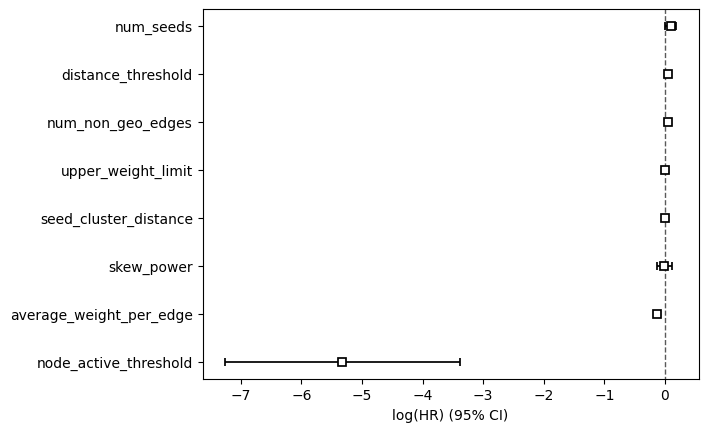

In [211]:
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='duration', event_col = 'state', show_progress=True)
cph.print_summary()
cph.plot()

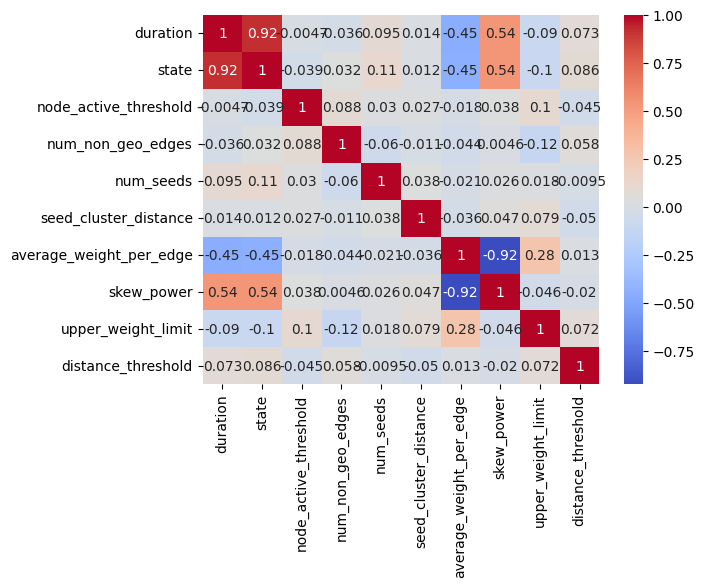

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = cox_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [118]:
# def load_simulations(file_path):
#     with open(file_path, 'rb') as f:
#         return pickle.load(f)

# simulations_time_series = load_simulations(pkl)
#
# activation_series = []
# for sim in simulations_time_series:
#     sim_id = sim['sim_id']
#     G = sim['graph']
#     activation_series.append(sim['activation_times'])
#
#     print(f"Sim {sim_id} — Nodes: {len(G)}, Activated: {sum(~np.isnan(sim['activation_times']))}")
#
# print(activation_series[0])

Sim 0 — Nodes: 200, Activated: 200
Sim 1 — Nodes: 200, Activated: 200
Sim 2 — Nodes: 200, Activated: 200
Sim 3 — Nodes: 200, Activated: 200
Sim 4 — Nodes: 200, Activated: 200
Sim 5 — Nodes: 200, Activated: 200
Sim 6 — Nodes: 200, Activated: 200
Sim 7 — Nodes: 200, Activated: 200
Sim 8 — Nodes: 200, Activated: 200
Sim 9 — Nodes: 200, Activated: 200
[12. 12. 13. 13. 13. 13. 12. 12. 12. 11. 11. 11. 10. 10. 10.  9.  9.  9.
  8.  8.  9.  7.  8.  8.  7.  7.  6.  6.  6.  5.  5.  5.  4.  4.  4.  3.
  3.  2.  1.  2.  1.  0.  1.  1.  2.  2.  2.  3.  3.  4.  4.  4.  5.  5.
  5.  6.  6.  7.  7.  8.  8.  8.  9.  9.  9. 10. 10. 10. 11. 11. 11. 11.
 11. 10. 10. 10.  9. 10. 10. 10. 11. 11. 11. 12. 12. 12. 13. 13. 13. 14.
 14. 14. 15. 15. 15. 15. 14. 14. 14. 13. 13. 13. 12. 12. 12. 11. 11. 11.
 10. 10. 10.  9.  9.  9.  8.  8.  8.  7.  7.  7.  6.  6.  6.  5.  5.  5.
  4.  4.  3.  3.  3.  2.  2.  2.  1.  2.  0.  1.  1.  1.  2.  2.  2.  2.
  1.  2.  1.  0.  2.  1.  2.  2.  3.  3.  2.  2.  2.  1.  0.  1.  